<a href="https://colab.research.google.com/github/Likelipop/algorithm-analysis/blob/main/Lab06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BÀI TẬP THỰC HÀNH PHÂN TÍCH THUẬT TOÁN TUẦN 6
---
1. Họ và tên: Trần Tiến Đạt
2. MSSV: 22110039

# Bài 1: Bài toán Knapsack (Subset Sum)

Cho một tập hợp A gồm n phần tử:

$$
A = \{a_1, a_2, \dots, a_n\}, \quad a_i \in \mathbb{R},\; a_i > 0
$$

Với một số thực dương \( S \), hãy viết chương trình tìm một tập con:

$$
\{a_{i_1}, a_{i_2}, \dots, a_{i_k}\} \subseteq A
$$

sao cho:

$$
a_{i_1} + a_{i_2} + \dots + a_{i_k} = S
$$

trong đó:

$$
i_j \ne i_l,\quad \forall j,l \in \{1,2,\dots,k\},\; j \ne l
$$

## Input

- Các giá trị: \( a_1, a_2, a_3, \dots, a_n \)
- Giá trị mục tiêu: \( S \)

## Output

- Một tập con:

$$
\{a_{i_1}, \dots, a_{i_k}\}
$$

thỏa mãn tổng các phần tử bằng \( S \).

---
# Phương pháp giải

Ở đây, em sẽ sử dụng phương pháp quy hoạch động để kiểm tra xem có thể chọn một số phần tử đầu tiên của tập $A$ sao cho tổng bằng giá trị mục tiêu $S$ hay không.

# Định nghĩa hàm mục tiêu

Gọi:

$$
F(i,j)
$$

là giá trị logic:

- $F(i,j)=1$: nếu có thể chọn một tập con từ $\{a_1,a_2,\dots,a_i\}$ sao cho tổng bằng $j$
- $F(i,j)=0$: nếu không thể

Trong đó:

- $i=0,1,2,\dots,n$
- $j=0,1,2,\dots,S$

# Các bài toán cơ sở

$$
F(0,0)=1
$$

(Với 0 phần tử, ta tạo được tổng 0)

$$
F(0,j)=0,\quad \forall j>0
$$

(Hiển nhiên ta không tìm cách để nhét bất kỳ món nào mà tổng bằng j lớn hơn không được)

$$
F(i,0)=1,\quad \forall i\ge 0
$$

(Luôn có thể bằng cách *Không nhét món nào* vào balo này để có thể đạt được tổng bằng 0)

# Công thức truy hồi

Với $i\ge 1$:

- Nếu $j<a_i$:

$$
F(i,j)=F(i-1,j)
$$

- Nếu $j\ge a_i$:

$$
F(i,j)=F(i-1,j)\lor F(i-1,j-a_i)
$$

Trong đó:

- $F(i-1,j)$: không chọn $a_i$
- $F(i-1,j-a_i)$: chọn $a_i$

# Kết quả cuối cùng của bài toán

$$
F(n,S)
$$

- Nếu $F(n,S)=1$ thì tồn tại tập con có tổng bằng $S$
- Nếu $F(n,S)=0$ thì không tồn tại

## CÀI ĐẶT GIẢI THUẬT

In [ ]:
import time
import random
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

def subset_sum_dp(A, S):
    """
    Solves the subset sum problem using dynamic programming to find a subset
    that sums to a specific target.

    Args:
        A (list[int]): A list of non-negative integers representing the set A.
        S (int): The target sum.

    Returns:
        list[int]: A subset of A whose sum is exactly S.
        None: If no such subset exists.
    """
    n = len(A)
    F = [[False] * (S + 1) for _ in range(n + 1)]

    for i in range(n + 1):
        F[i][0] = True

    for i in range(1, n + 1):
        for j in range(1, S + 1):
            if j < A[i - 1]:
                F[i][j] = F[i - 1][j]
            else:
                F[i][j] = F[i - 1][j] or F[i - 1][j - A[i - 1]]

    if not F[n][S]:
        return None

    subset = []
    i, j = n, S
    while i > 0 and j > 0:
        if F[i - 1][j]:
            i -= 1
        else:
            subset.append(A[i - 1])
            j -= A[i - 1]
            i -= 1

    return subset




# Tiến hành thưc nghiệm

Để đánh giá tốc độ chạy của thuật toán trên, ta tiến hành thí nghiệm bằng cách thay đổi số lượng phần tử của mảng đầu vào và đo thời gian thực thi tương ứng.

## Các bước thực hiện

- Chọn số phần tử $n$ tăng dần từ $50$ đến $1000$, mỗi lần tăng $50$.
- Giữ cố định giá trị cần tìm tổng là:

$$
S = 200
$$

- Với mỗi giá trị $n$, tạo ngẫu nhiên một mảng $A$ gồm $n$ phần tử.
- Mỗi phần tử trong mảng được sinh ngẫu nhiên trong đoạn từ $0$ đến $500$.

## Đo thời gian chạy

- Với mỗi giá trị $n$, chương trình chạy thuật toán `subset_sum_dp(A, S)` tổng cộng $20$ lần.
- Ở mỗi lần chạy:
  - Ghi nhận thời gian bắt đầu.
  - Thực hiện thuật toán.
  - Ghi nhận thời gian kết thúc.
- Thời gian chạy của một lần thực nghiệm được tính bằng:

$$
t = t_{kết\ thúc} - t_{bắt\ đầu}
$$

## Tính thời gian trung bình

Sau $20$ lần chạy, thời gian trung bình được tính theo công thức:

$$
\overline{t} = \frac{t_1+t_2+\dots+t_{20}}{20}
$$

Trong đó:

- $t_1, t_2, \dots, t_{20}$ là thời gian của từng lần chạy.

## Lưu kết quả

Kết quả thu được gồm:

- Giá trị $n$
- Thời gian chạy trung bình tương ứng

Sau đó lưu vào bảng dữ liệu để thuận tiện cho việc vẽ biểu đồ và phân tích.

In [ ]:
n_values = list(range(50, 1001, 50))
S = 200
num_trials = 20
average_times = []

for n in n_values:
    total_time = 0.0
    for _ in range(num_trials):
        A = [random.randint(0, 500) for _ in range(n)]

        start_time = time.perf_counter()
        subset_sum_dp(A, S)
        end_time = time.perf_counter()

        total_time += (end_time - start_time)

    avg_time = total_time / num_trials
    average_times.append(avg_time)

df = pd.DataFrame({
    'n': n_values,
    'Average Time (seconds)': average_times
})

df.head()

,n,Average Time (seconds)
0,50,0.000955
1,100,0.001981
2,150,0.002625
3,200,0.003534
4,250,0.004353


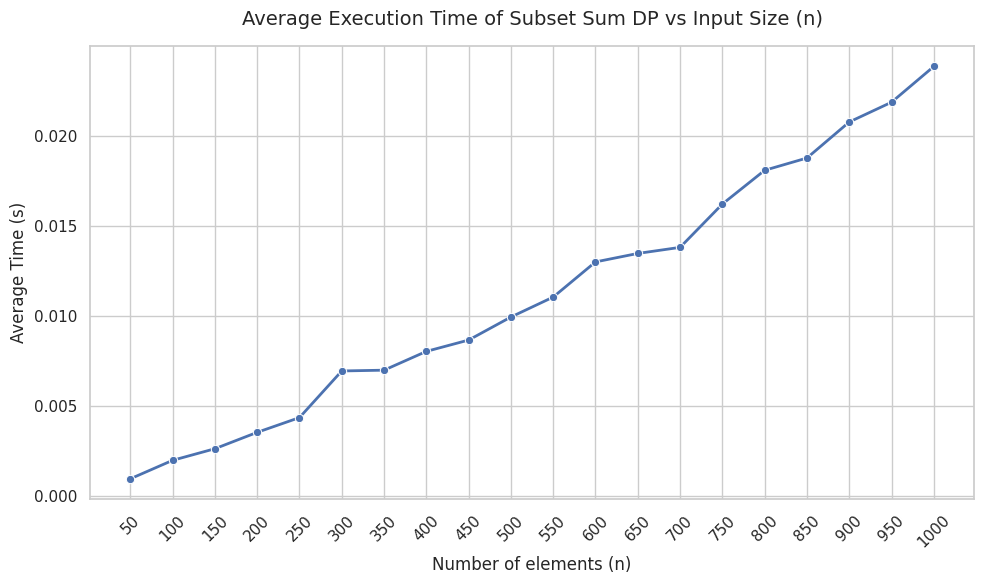

In [ ]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

plot = sns.lineplot(
    data=df,
    x='n',
    y='Average Time (seconds)',
    marker='o',
    color='b',
    linewidth=2
)

plt.title('Average Execution Time of Subset Sum DP vs Input Size (n)', fontsize=14, pad=15)
plt.xlabel('Number of elements (n)', fontsize=12)
plt.ylabel('Average Time (s)', fontsize=12)
plt.xticks(n_values, rotation=45)
plt.tight_layout()
plt.show()

**Nhận xét:** Với số lượng đồ vật là 200 (giữ nguyên) và n tăng dần, ta thấy thời gian thực hiện thuật toán cũng tăng tuyến tính theo n.

Bên cạnh đó, ta thấy rằng thuật toán sử dụng kỹ thuật qhd trên thực hiện duyệt qua hai vòng lập for s và for n để tính toán tất cả các bài toán con f_ij. Nên từ đó ta thấy rằng chúng có độ phức tạp O(N*S).